# Homework 05: Shortest paths, maximum flow, and duality

**ISyE 524 — Fall 2026**  
**Due:** Monday, October 12, 2026, at 11:59 p.m. (Madison time).

Complete all three problems, which use the network and LP-duality material from Lectures 9–10. For Problems 1–2, use the standard minimum-cost network flow formulation from `mcnf.ipynb`. Write its specialization for each problem before adapting and reusing the Julia/JuMP model. Explain the data, variable domains, objective, constraints, and relevant units. Use continuous variables. Problem 3 requires mathematical reasoning; code is not required.

Submit one PDF to Gradescope and mark which pages belong to each problem. **You will not receive full marks unless you mark the pages.**


## Getting started and written answers

Follow [Assignments and PDF Submission](https://github.com/jlinderoth/isye524-students-julia/blob/main/docs/canvas-assignment-workflow.md). In VS Code, use **Tasks: Run Task** to run **ISyE 524: Update course repository**, then **ISyE 524: Start an assignment from its template**, entering `hw05`. Open `student-work/hw05/hw05.ipynb`. An existing working copy will not be overwritten.

For **every written part**, type LaTeX mathematics in Markdown or insert a clear photograph/scan of handwritten work. Include the answer and reasoning together and label the subparts; no duplicate transcription is required. Julia/JuMP implementations belong in code cells.

Use `$x_1 \geq 0$` for inline mathematics and `$$x_1+x_2\leq5$$` for display mathematics. Run the Markdown cell to render it.

For handwritten work, edit a Markdown cell in VS Code, drag in a cropped PNG/JPEG, and choose **Insert Image as Attachment**. Alternatively, put the image beside your working notebook under `student-work/hw05/images/` and insert `![My answer](images/problem1.png)`. Keep external images with the notebook. See [Images and handwritten work](https://github.com/jlinderoth/isye524-students-julia/blob/main/docs/assignments.md#images-and-handwritten-work).

Back up `student-work/hw05/` separately; Git does not back up your answers or images. After completing the notebook, export it with the course PDF task, inspect `submissions/hw05.pdf` for readable mathematics, tables, outputs, and images, and submit that PDF to Gradescope.


## Computational setup

Use JuMP and HiGHS for Problems 1–2. Start from the standard [minimum-cost network flow notebook (`mcnf.ipynb`)](https://github.com/jlinderoth/isye524-students-julia/blob/main/notebooks/12-mcnf.ipynb), available as `notebooks/12-mcnf.ipynb` in the student repository. Reuse its minimum-cost objective, **outflow − inflow = net supply** balances, and lower/upper arc bounds for every network instance, including maximum flow. Change the network data rather than writing a separate optimization model for each problem. You may wrap the standard model code in a function to reuse it.

Match the notebook's data names: `nodes`, `arcs`, `c`, `b`, `ℓ` (lower bounds), and `u` (upper bounds). The supplied names have suffixes to distinguish instances. Use dictionaries for `b` when node labels are symbols or strings so that `b[i]` is indexed by the node label. Print the termination status and check that the solver found an optimal solution before reading its values. Keep data preparation separate from the model implementation.

The restaurant and maximum-flow data are supplied below. Keep `data/roads.csv` with this notebook for the larger road-network instance in Problem 1(c). All supplied cells run without completed answers. Report the requested summaries rather than printing a large model or every arc flow.

AI tools may help debug your own code, explain syntax or error messages, and critique your work. They should not replace constructing your formulation, implementation, or written solution. Complete the required collaboration and LLM-use statement at the end.


In [1]:
using JuMP, HiGHS, CSV, DataFrames, Printf
import MathOptInterface as MOI


## 1: Taste of Madison — and a larger road network

Some friends are visiting Madison. You want to drive from **Short Stack to Alchemy**, possibly stopping at other restaurants along the way, while minimizing total driving time. You do **not** have to visit every restaurant.

The directed connections and travel times are given below. A dash means that there is no direct connection in that direction. Only the listed connections may be used; do not add their reverses.

| From / to | G | O | R | I | W | A |
| :--- | ---: | ---: | ---: | ---: | ---: | ---: |
| S | 4 | 6 | 5 | — | — | — |
| G | — | 1 | — | 7 | — | — |
| O | — | — | 2 | 5.5 | 4 | — |
| R | — | — | — | — | 5 | — |
| I | — | — | — | — | 1 | 6 |
| W | — | — | — | — | — | 8 |

All times are in minutes. The node labels are **S:** Short Stack; **G:** Great Dane; **O:** Old Fashioned; **R:** Red Sushi; **I:** Ian's at Garver; **W:** Weary Traveler; **A:** Alchemy.

### 1(a): Formulate and solve the shortest-path problem

Formulate a shortest path from source $s$ to destination $t$ in a directed network with positive arc travel times **as a minimum-cost network flow problem**, using the standard formulation in `mcnf.ipynb`. Let $\mathcal N$ and $\mathcal E$ denote the nodes and directed arcs, and let the continuous variable $x_{ij}$ denote flow on arc $(i,j)$. Specify the data $c_{ij}$, $b_i$, $\ell_{ij}$, and $u_{ij}$ for this application and write the resulting indexed LP. Explain the supplies/demand you assign and how a unit of flow represents a route.

Adapt the standard model code from `mcnf.ipynb` to the restaurant data below. Keep this model implementation for reuse in 1(c) and Problem 2. Report an optimal route **in travel order** and its total time. Briefly explain why integer-variable declarations are not needed to obtain an optimal path in this instance.


**Your mathematical formulation and reasoning:**

| Symbol | Parameter | Units |
| :--- | ---: | ---: |
| $c_{ij}$ | Drive Time | Min |
| $b_{i}$ | Supply |  |
| $u_{ij}$ | Upper Limit |  |
| $l_{ij}$ | Lower Limit |  |




$$
\begin{aligned}
\min \quad \sum_{(i,j) \epsilon \varepsilon} x_{ij}c_{ij} \\
\end{aligned}
$$  


$$
\begin{aligned}
\text{Subject To:}\\
\ \sum_{(i,j) \epsilon \varepsilon}x_{ij} - \sum_{(i,j) \epsilon \varepsilon}x_{ji} = b_i \quad \forall i \epsilon N\\
\ \ell_{ij} \leq x_{ij} \leq u_{ij} \quad \forall(i,j) \epsilon \varepsilon
\end{aligned}
$$  
[Type your answer here, or insert a clear photograph/scan of handwritten work.]


In [ ]:
nodes_small = [:S, :G, :O, :R, :I, :W, :A]
arcs_small = [(:S,:G), (:S,:O), (:S,:R), (:G,:O), (:G,:I),
           (:O,:R), (:O,:I), (:O,:W), (:R,:W), (:I,:W),
           (:I,:A), (:W,:A)]
c_small = Dict(zip(arcs_small, [4,6,5,1,7,2,5.5,4,5,1,6,8]))
s_small, t_small = :S, :A;


In [ ]:
# Prepare b, ℓ, and u for the restaurant network.
# Adapt the standard mcnf.ipynb model code and keep it for reuse.


**Your results and interpretation:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


### 1(b): Does choosing the cheapest next arc work?

Starting at S, repeatedly take the outgoing arc with the smallest travel time until you reach A. Work this out by hand; you do not need to program this rule. Report its route and total time, compare with 1(a), and explain why a locally cheapest choice can lead to a worse complete route.


**Your answer and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


### 1(c): The same model on a larger road network

The supplied file `data/roads.csv` describes a fixed synthetic road network with **900 intersections and 2,914 directed arcs**. The intersections lie on a $30\times30$ grid and are numbered row by row. A connected set of roads between neighboring intersections was generated randomly. Each road permits travel in both directions, with positive travel times that may differ by direction.

Each CSV row gives `from`, `to`, and `minutes` for one directed arc. This is already a fixed instance: **do not generate new random data**. Find the shortest route from intersection **1** to intersection **900** by reusing the standard minimum-cost network flow formulation and model implementation from 1(a). Prepare the new node/arc sets, costs, supplies, and lower/upper bounds as separate data.

Report only the **minimum travel time** and the **number of road segments in an optimal route**. Do not print the full model, the entire route, or all arc flows. No new formulation or greedy comparison is required for this part.


In [ ]:
# Locate this assignment when the kernel starts beside the notebook or
# at the repository root. Prefer an existing personal copy.
assignment_dir = if isfile(joinpath(pwd(), "hw05.ipynb"))
    pwd()
elseif isdir(joinpath(pwd(), "student-work", "hw05"))
    joinpath(pwd(), "student-work", "hw05")
else
    joinpath(pwd(), "assignments", "hw05")
end
road_file = joinpath(assignment_dir, "data", "roads.csv")
isfile(road_file) || error(
    "Missing roads.csv in $(dirname(road_file)). " *
    "Keep the complete data folder beside your HW05 notebook."
)
roads = CSV.read(road_file, DataFrame)
nodes_large = 1:900
arcs_large = [(r.from, r.to) for r in eachrow(roads)]
c_large = Dict((r.from, r.to) => r.minutes for r in eachrow(roads))
s_large, t_large = 1, 900
println("Loaded ", length(nodes_large), " intersections and ",
        length(arcs_large), " directed arcs.")


In [ ]:
# Prepare the large-instance MCNF data and reuse the same model.
# Report the travel time and number of road segments.


**Your reported results:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


## 2: Maximum flow and capacity upgrades

Consider the directed network below. Each arc label is its capacity in units of flow per hour. Find the maximum flow that can be sent from source $s$ to sink $t$. Intermediate nodes neither create nor consume flow.

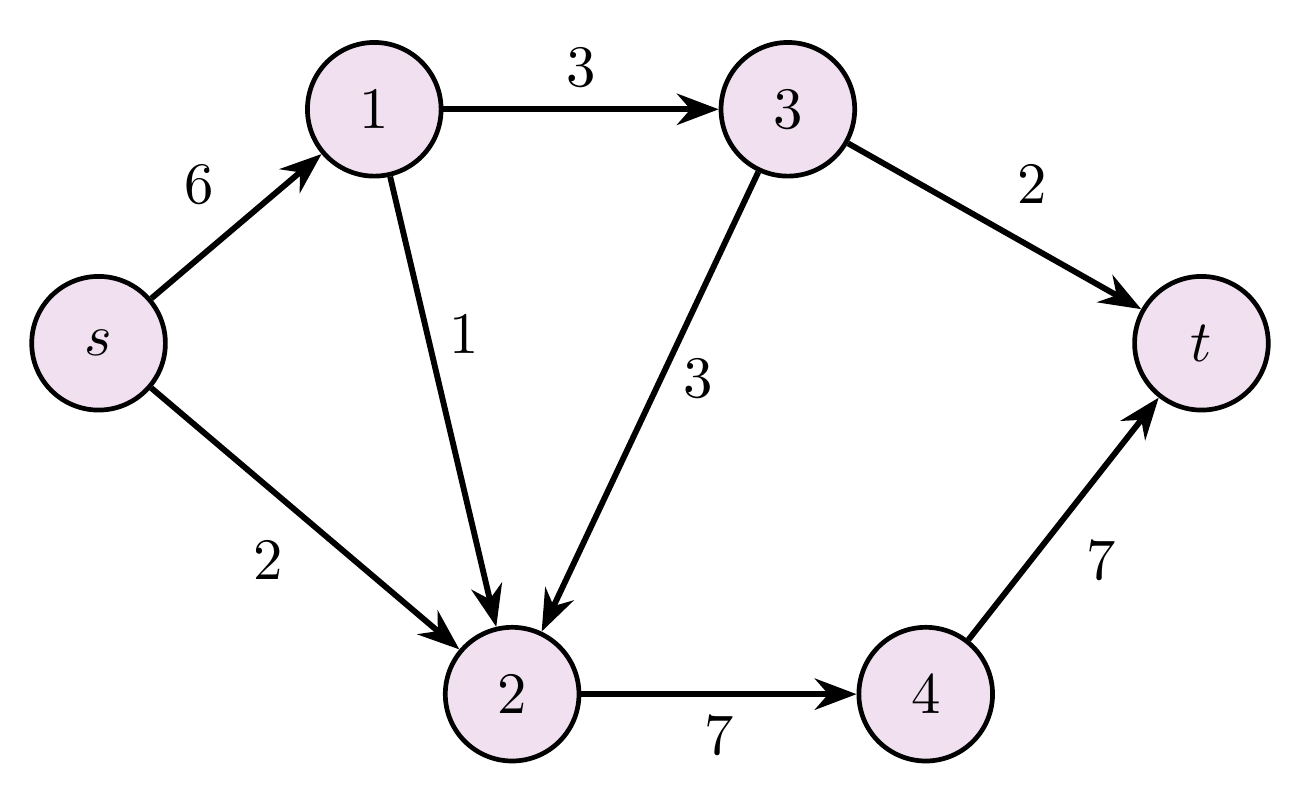{width=75%}

### 2(a): Formulate with a feedback arc

Formulate this maximum-flow problem **as a minimum-cost network flow problem** using the same standard formulation from `mcnf.ipynb` and 1(a). Let $\mathcal N$ be the nodes and $\mathcal E$ the physical arcs, and let the continuous variable $x_{ij}$ denote flow per hour on each arc. Add an artificial **feedback arc $(t,s)$**, giving the augmented arc set $\overline{\mathcal E}=\mathcal E\cup\{(t,s)\}$.

Specify $c_{ij}$, $b_i$, $\ell_{ij}$, and $u_{ij}$ on this augmented network and write the resulting indexed **minimization** LP. Choose the costs so that minimizing total cost maximizes throughput. Explain the feedback arc's capacity, why every node has zero net supply, how its flow measures total throughput, and how the minimum objective value relates to the maximum flow.


**Your mathematical formulation and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


### 2(b): Implement and interpret

Reuse the standard minimum-cost network flow model code from 1(a), changing only its input data to the augmented network from 2(a). The supplied arc set contains only the physical arcs; add the feedback arc when preparing the data. Keep the standard minimization objective and flow-balance equations. Report the maximum flow and the flow on each physical arc and the feedback arc. Explain how the flow leaving the source reaches the sink, including any splitting or merging.


In [ ]:
# Strings "1", ..., "4" label the intermediate nodes in the figure.
nodes_flow = ["s", "1", "2", "3", "4", "t"]
arcs_flow = [("s","1"), ("s","2"), ("1","2"), ("1","3"),
          ("3","2"), ("2","4"), ("3","t"), ("4","t")]
u_flow = Dict(zip(arcs_flow, [6.0,2.0,1.0,3.0,3.0,7.0,2.0,7.0]))
s_flow, t_flow = "s", "t";


In [ ]:
# Prepare the augmented network and its c, b, ℓ, and u data.
# Reuse the MCNF model from 1(a); report throughput and arc flows.


**Your results and interpretation:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


### 2(c): Which capacity upgrade helps?

Consider three separate experiments, each starting from the **original** capacities:

1. Increase the capacity of $(s,1)$ from 6 to 7.
2. Increase the capacity of $(1,3)$ from 3 to 4.
3. Increase the capacity of $(4,t)$ from 7 to 8.

For each experiment, change only the relevant upper-bound data and re-solve with the same minimum-cost network flow model. Using your **original optimal solution from 2(b)**, compare the increase in maximum flow with the upgraded arc's **unused capacity**, defined as $u_{ij}-x^0_{ij}$, where $x^0_{ij}$ is its flow in that original solution. Report a table with the arc's original optimal flow, original capacity, unused capacity, new maximum throughput, and improvement over the base case. Use the same original solution for all three comparisons.

What relationship do you observe between unused capacity and the effect of an upgrade? Which upgrade should be chosen if all three have the same cost and the goal is to increase throughput? Explain the results using node balances and capacity limits. You do not need minimum-cut theory or the dual of the maximum-flow LP.


In [ ]:
# Use the original solution from 2(b) to compute unused capacities.
# Change the relevant upper bound in each independent experiment.
# Reuse the MCNF model and report the requested comparison table.


**Your answer and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


## 3: Duality — bounds and optimality certificates

Consider the primal LP

$$
\begin{aligned}
\max\quad &3x_1+x_2\\
\text{s.t.}\quad &4x_1+x_2\le7,\\
&5x_1+2x_2\le10,\\
&x_1,x_2\ge0.
\end{aligned}
$$

This problem is about mathematical reasoning. **No code is required.** In 3(c), use complementary slackness to construct a dual solution complementary to the given primal solution. In each optimality argument, check feasibility and explain how equality of objective values and weak duality certify optimality. A solver result is not a substitute for the requested reasoning.

### 3(a): Form the dual

Write the dual LP, using $y_1,y_2$ for the dual variables. Include the objective, every constraint, and the sign restrictions.


**Your answer and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


### 3(b): What weak duality actually says

For **any** feasible primal vector $x$ and feasible dual vector $y$, prove directly that
$$3x_1+x_2\le7y_1+10y_2.$$
Build the argument from the primal and dual constraints, and identify where the nonnegativity of $x$ and of $y$ is needed.

Now check the candidate vectors $\bar x=(1,1)$ and $\bar y=(1/2,1/4)$. Use their objective values to give an interval containing the optimal primal value. Do these bounds permit a feasible primal vector with objective value 6.5? Do they prove that objective value 6 is attainable? Explain both answers using only the information from these two feasible vectors.


**Your answer and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


### 3(c): Find a complementary dual solution and certify optimality

Verify that the proposed primal vector $\hat x=(4/3,5/3)$ is feasible. Use the complementary slackness conditions to find a dual-feasible solution $\hat y$ complementary to $\hat x$. Explain which conditions determine $\hat y$, verify feasibility and all complementary slackness conditions, and use equality of objective values and weak duality to prove that both solutions are optimal. Explain why satisfying the complementary slackness equations without checking feasibility would be insufficient.


**Your answer and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


### 3(d): More of the second resource

Change the right-hand side of the **second primal constraint from 10 to 12**. All other data stay fixed.

Determine whether the dual vector from 3(c) is still feasible. Use it and weak duality to obtain an upper bound on the new optimal primal value. Find a feasible primal point that attains this bound and prove optimality by checking its constraints and objective.


**Your answer and reasoning:**

[Type your answer here, or insert a clear photograph/scan of handwritten work.]


## Collaboration and LLM-use statement — required

Complete this statement as the **very last part of your homework**. Be specific enough that a reader can understand what work you did yourself and how others or LLMs helped you learn.

- **People:** Give the name of every person you collaborated with, identify the problem/subpart you discussed, and explain the nature of the collaboration. If you worked alone, explicitly state that you did not collaborate with anyone.
- **LLMs/tools:** Name every LLM or AI assistant you used and identify the model/version as precisely as available. If the interface did not show a model/version, say so. If you used none, explicitly state that you did not use an LLM or AI assistant.
- **Specific assistance and learning:** For each tool, identify the problem/subpart, describe what you asked it to help with, what suggestions you used or rejected, and how the interaction helped you understand the mathematics or implementation. Explain how you checked the suggestions. “I used ChatGPT for help” is not sufficiently specific.

Disclosure does not replace the requirement that your submitted formulation, implementation, and explanation be your own work and that you understand them.


**People and collaboration:**

[Names, problem/subparts, and what you discussed; or explicitly state that you worked alone.]

**LLMs/tools and models:**

[Tool names and models/versions, or explicitly state that you used none.]

**How I used the assistance, what I learned, and how I checked it:**

[Specific details for each tool and relevant problem/subpart; state not applicable if you used none.]
